In [1]:
import pandas as pd
import numpy as np
import random

rows = []

for i in range(50000):

    study = round(np.random.normal(7,2),1)
    study = max(0,min(study,14))

    sleep = round(np.random.normal(6.5,1.5),1)
    sleep = max(3,min(sleep,10))

    stress = int(np.random.normal(5.5,2))
    stress = max(1,min(stress,10))

    trend = random.choice([
        "Improving",
        "Stable",
        "Declining",
        "Fluctuating"
    ])

    burnout_score = (
        study*0.3 +
        (10-sleep)*0.4 +
        stress*0.5
    )

    if trend == "Declining":
        burnout_score += 2
    elif trend == "Fluctuating":
        burnout_score += 1

    if burnout_score >= 10:
        risk = "High"
    elif burnout_score >= 6:
        risk = "Moderate"
    else:
        risk = "Low"

    rows.append([study,sleep,stress,trend,risk])

df = pd.DataFrame(rows,columns=[
    "studyHours",
    "sleepHours",
    "stressLevel",
    "performanceTrend",
    "burnoutRisk"
])

df.to_csv("burnout_predictor.csv",index=False)

df.head()

,studyHours,sleepHours,stressLevel,performanceTrend,burnoutRisk
0,7.0,5.8,4,Stable,Low
1,7.4,7.5,7,Fluctuating,Moderate
2,7.3,7.0,1,Stable,Low
3,7.3,6.5,3,Stable,Low
4,5.7,6.3,8,Declining,Moderate


In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("burnout_predictor.csv")

df.head()

,studyHours,sleepHours,stressLevel,performanceTrend,burnoutRisk
0,7.0,5.8,4,Stable,Low
1,7.4,7.5,7,Fluctuating,Moderate
2,7.3,7.0,1,Stable,Low
3,7.3,6.5,3,Stable,Low
4,5.7,6.3,8,Declining,Moderate


In [4]:
label_perf = LabelEncoder()
label_risk = LabelEncoder()

df["performanceTrend"] = label_perf.fit_transform(df["performanceTrend"])
df["burnoutRisk"] = label_risk.fit_transform(df["burnoutRisk"])

In [5]:
X = df.drop("burnoutRisk",axis=1)
y = df["burnoutRisk"]

In [6]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [7]:
ada = AdaBoostClassifier(n_estimators=100)

grad = GradientBoostingClassifier(n_estimators=100)

rf = RandomForestClassifier(n_estimators=100)

In [8]:
ada.fit(X_train,y_train)
grad.fit(X_train,y_train)
rf.fit(X_train,y_train)

RandomForestClassifier()

In [9]:
ada_pred = ada.predict(X_test)
grad_pred = grad.predict(X_test)
rf_pred = rf.predict(X_test)

In [10]:
from sklearn.metrics import accuracy_score

ada_acc = accuracy_score(y_test,ada_pred)
grad_acc = accuracy_score(y_test,grad_pred)
rf_acc = accuracy_score(y_test,rf_pred)

print("AdaBoost Accuracy:",ada_acc)
print("Gradient Boost Accuracy:",grad_acc)
print("Random Forest Accuracy:",rf_acc)

AdaBoost Accuracy: 0.9046
Gradient Boost Accuracy: 0.9763
Random Forest Accuracy: 0.9905


In [11]:
import pandas as pd

results = pd.DataFrame({
    "Model":["AdaBoost","Gradient Boost","Random Forest"],
    "Accuracy":[ada_acc,grad_acc,rf_acc]
})

results

,Model,Accuracy
0,AdaBoost,0.9046
1,Gradient Boost,0.9763
2,Random Forest,0.9905


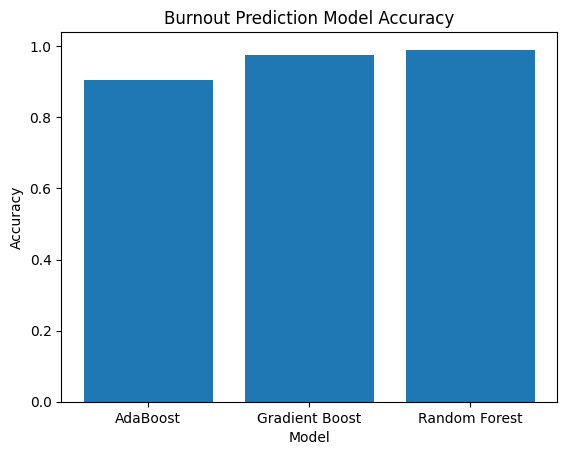

In [12]:
import matplotlib.pyplot as plt

plt.bar(results["Model"],results["Accuracy"])
plt.title("Burnout Prediction Model Accuracy")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.show()

In [18]:
import pickle

pickle.dump(rf,open("burnout_model_rf.pkl","wb"))

In [20]:
from google.colab import files
files.download("burnout_model_rf.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
model = pickle.load(open("burnout_model_rf.pkl", "rb"))

In [23]:
import pickle

model = pickle.load(open("burnout_model_rf.pkl","rb"))


studyHours = 9
sleepHours = 5
stressLevel = 7
performanceTrend = 1

data = [[studyHours,sleepHours,stressLevel,performanceTrend]]

prediction = model.predict(data)

labels = ["Low","Moderate","High"]

print("Burnout Risk:",labels[prediction[0]])

Burnout Risk: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
